# Smart Procurement: Predicting Delivery Delays & Reward-Based Planning


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay
)


## 1. Load Data


In [2]:
deliveries = pd.read_csv('Deliveries.csv')
projects   = pd.read_csv('Projects.csv')
factories  = pd.read_csv('Factories.csv')
external   = pd.read_csv('External_Factors.csv')
print('Deliveries:', deliveries.shape)
print('Projects:',   projects.shape)
print('Factories:',  factories.shape)
print('External:',   external.shape)


Deliveries: (1200, 8)
Projects: (200, 5)
Factories: (5, 6)
External: (30, 3)


## 2. Merge & Feature Engineering


In [3]:
df = deliveries.merge(projects,  on='project_id')
df = df.merge(factories, on='factory_id')
df = df.merge(external,  on='date')

# Haversine distance from factory to project (validates distance_km)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['calc_distance_km'] = haversine(
    df['latitude_x'].values, df['longitude_x'].values,
    df['latitude_y'].values, df['longitude_y'].values
)

df['delay_hours'] = df['actual_time_hours'] - df['expected_time_hours']

df['date']  = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['day']   = df['date'].dt.day

drop_cols = ['actual_time_hours', 'delay_hours', 'date',
             'delivery_id', 'latitude_x', 'longitude_x',
             'latitude_y', 'longitude_y']

df['delay_hours'] = deliveries['actual_time_hours'] - deliveries['expected_time_hours']

# Target
y = df['delay_flag'].copy()
X = df.drop(columns=drop_cols + ['delay_flag'])

print('Class distribution:')
print(y.value_counts())
print('\nFeatures:', X.columns.tolist())


Class distribution:
delay_flag
1    1196
0       4
Name: count, dtype: int64

Features: ['factory_id', 'project_id', 'distance_km', 'expected_time_hours', 'demand', 'priority_level', 'base_production_per_week', 'production_variability', 'max_storage', 'weather_index', 'traffic_index', 'calc_distance_km', 'month', 'day']


## 3. Exploratory Data Analysis


In [4]:
df.describe()


,distance_km,expected_time_hours,actual_time_hours,delay_flag,date,latitude_x,longitude_x,demand,latitude_y,longitude_y,base_production_per_week,production_variability,max_storage,weather_index,traffic_index,calc_distance_km,delay_hours,month,day
count,1200.000000,1200.000000,1200.000000,1200.000000,1200,1200.000000,1200.000000,1200.0,1200.000000,1200.000000,1200.000000,1200.000000,1200.0,1200.000000,1200.000000,1200.000000,1200.000000,1200.0,1200.000000
mean,463.227942,11.580633,19.111692,0.996667,2026-04-15 02:08:24.000000256,15.895219,75.844140,1.0,15.269424,76.649068,39.143333,0.119042,6.0,0.590908,0.551750,455.910579,7.531058,4.0,15.089167
min,18.250000,0.460000,0.610000,0.000000,2026-04-01 00:00:00,12.004163,72.041479,1.0,12.451293,73.467236,30.000000,0.060000,6.0,0.040000,0.080000,18.233184,0.150000,4.0,1.000000
25%,298.850000,7.470000,12.107500,1.000000,2026-04-07 00:00:00,14.031323,73.975009,1.0,13.454600,75.566662,31.000000,0.080000,6.0,0.480000,0.320000,297.812104,3.967500,4.0,7.000000
50%,463.880000,11.600000,18.750000,1.000000,2026-04-15 00:00:00,15.598033,75.762405,1.0,14.996321,76.808920,42.000000,0.140000,6.0,0.560000,0.590000,460.880242,6.865000,4.0,15.000000
75%,634.120000,15.850000,25.677500,1.000000,2026-04-23 00:00:00,17.570434,77.685303,1.0,16.774801,77.775990,43.000000,0.150000,6.0,0.840000,0.740000,622.641459,10.325000,4.0,23.000000
max,1002.630000,25.070000,44.900000,1.000000,2026-04-30 00:00:00,19.970030,79.981924,1.0,18.929409,79.605714,49.000000,0.170000,6.0,0.970000,1.000000,983.940854,25.770000,4.0,30.000000
std,213.220859,5.330427,9.275820,0.057663,NaN,2.236787,2.295247,0.0,2.323419,2.057289,7.392451,0.042487,0.0,0.276377,0.267023,210.228082,4.549529,0.0,8.659217


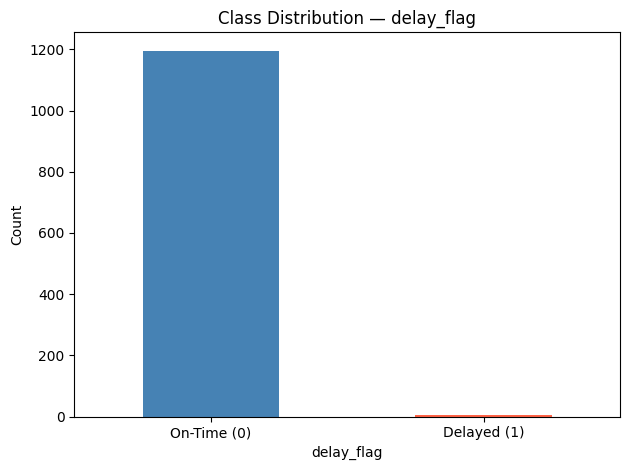

Note: dataset is heavily imbalanced — 1196 delayed vs 4 on-time


In [5]:
y.value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.xticks([0,1], ['On-Time (0)','Delayed (1)'], rotation=0)
plt.title('Class Distribution — delay_flag')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print('Note: dataset is heavily imbalanced — 1196 delayed vs 4 on-time')


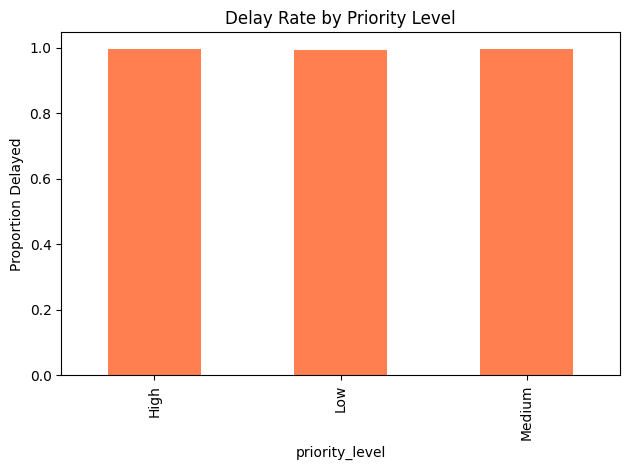

In [6]:

df.groupby('priority_level')['delay_flag'].mean().plot(kind='bar', color='coral')
plt.title('Delay Rate by Priority Level')
plt.ylabel('Proportion Delayed')
plt.tight_layout()
plt.show()


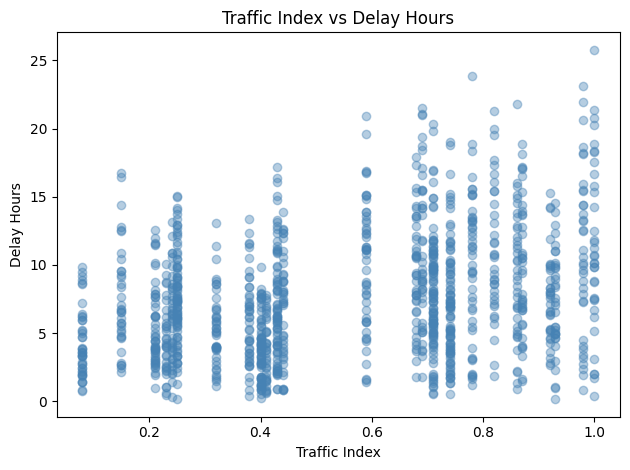

In [7]:

plt.scatter(df['traffic_index'], df['delay_hours'], alpha=0.4, color='steelblue')
plt.xlabel('Traffic Index')
plt.ylabel('Delay Hours')
plt.title('Traffic Index vs Delay Hours')
plt.tight_layout()
plt.show()


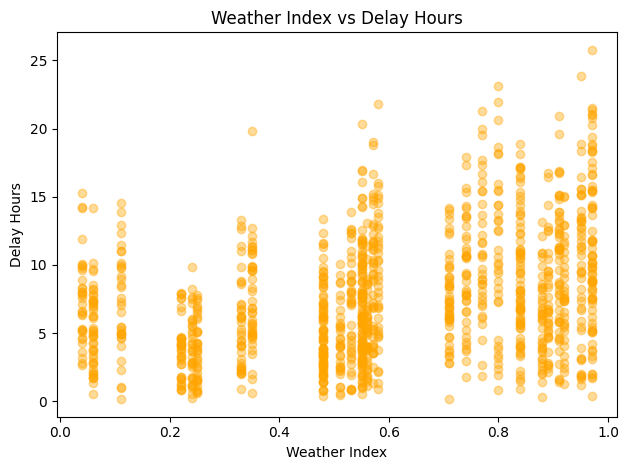

In [8]:

plt.scatter(df['weather_index'], df['delay_hours'], alpha=0.4, color='orange')
plt.xlabel('Weather Index')
plt.ylabel('Delay Hours')
plt.title('Weather Index vs Delay Hours')
plt.tight_layout()
plt.show()


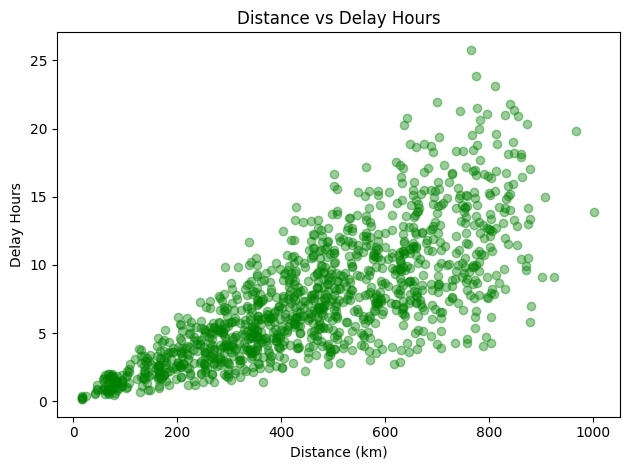

In [9]:
plt.scatter(df['distance_km'], df['delay_hours'], alpha=0.4, color='green')
plt.xlabel('Distance (km)')
plt.ylabel('Delay Hours')
plt.title('Distance vs Delay Hours')
plt.tight_layout()
plt.show()


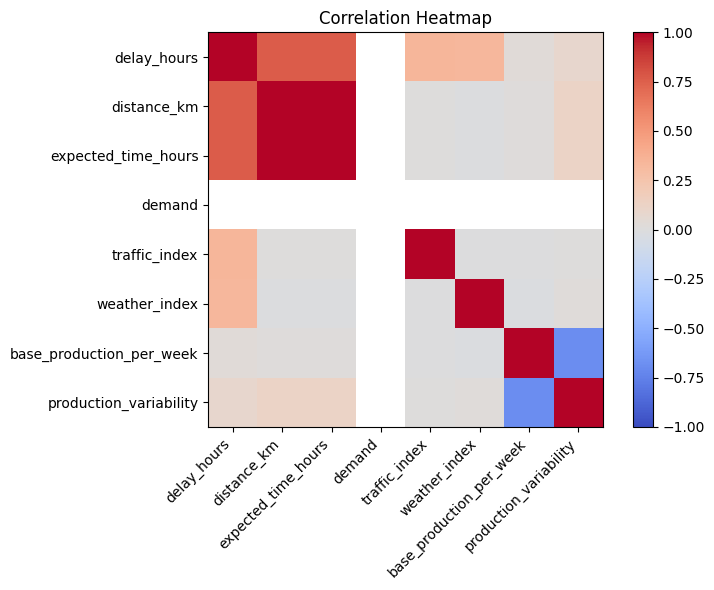

In [10]:
num_cols = ['delay_hours','distance_km','expected_time_hours',
            'demand','traffic_index','weather_index',
            'base_production_per_week','production_variability']
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticklabels(num_cols)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


## 4. Preprocessing


In [11]:
cat_cols = ['priority_level', 'factory_id', 'project_id']
num_cols = [
    'distance_km', 'calc_distance_km', 'expected_time_hours',
    'demand', 'base_production_per_week', 'production_variability',
    'max_storage', 'weather_index', 'traffic_index', 'month', 'day'
]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', 'passthrough', num_cols)
])



In [12]:
time_target=df["expected_time_hours"]

time_features=df.drop(columns=[
"expected_time_hours",
"delay_hours"
])

cat_time=["priority_level","factory_id","project_id"]

num_time=[
"distance_km",
"demand",
"base_production_per_week",
"production_variability",
"weather_index",
"traffic_index",
"month",
"day"
]

In [13]:
preprocessor_time=ColumnTransformer(
[
("cat",OneHotEncoder(handle_unknown="ignore"),cat_time),
("num","passthrough",num_time)
]
)

In [14]:
from sklearn.ensemble import RandomForestRegressor
time_model=Pipeline(
[
("prep",preprocessor_time),
("rf",RandomForestRegressor(n_estimators=200,random_state=42))
]
)

In [15]:
time_model.fit(time_features,time_target)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['priority_level',
                                                   'factory_id',
                                                   'project_id']),
                                                 ('num', 'passthrough',
                                                  ['distance_km', 'demand',
                                                   'base_production_per_week',
                                                   'production_variability',
                                                   'weather_index',
                                                   'traffic_index', 'month',
                                                   'day'])])),
                ('rf',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [16]:
import joblib

joblib.dump(time_model,"time_model.pkl")

['time_model.pkl']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train size:', X_train.shape, '| Test size:', X_test.shape)


Train size: (960, 14) | Test size: (240, 14)


## 5. Baseline Model — Logistic Regression


In [18]:
baseline = Pipeline([
    ('prep', preprocessor),
    ('lr',   LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

baseline.fit(X_train, y_train)
pred_base = baseline.predict(X_test)

print(' Logistic Regression ')
print(classification_report(y_test, pred_base, target_names=['On-Time','Delayed']))
print('ROC-AUC:', round(roc_auc_score(y_test, baseline.predict_proba(X_test)[:,1]), 4))


 Logistic Regression 
              precision    recall  f1-score   support

     On-Time       0.00      0.00      0.00         1
     Delayed       1.00      1.00      1.00       239

    accuracy                           1.00       240
   macro avg       0.50      0.50      0.50       240
weighted avg       0.99      1.00      0.99       240

ROC-AUC: 0.8285


## 6. Random Forest Classifier


In [19]:
model = Pipeline([
    ('prep', preprocessor),
    ('rf',   RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',   
        random_state=42
    ))
])

model.fit(X_train, y_train)
pred = model.predict(X_test)

print('Random Forest Classifier ')
print(classification_report(y_test, pred, target_names=['On-Time','Delayed']))
print('ROC-AUC:', round(roc_auc_score(y_test, model.predict_proba(X_test)[:,1]), 4))


Random Forest Classifier 
              precision    recall  f1-score   support

     On-Time       0.00      0.00      0.00         1
     Delayed       1.00      1.00      1.00       239

    accuracy                           1.00       240
   macro avg       0.50      0.50      0.50       240
weighted avg       0.99      1.00      0.99       240

ROC-AUC: 0.9833


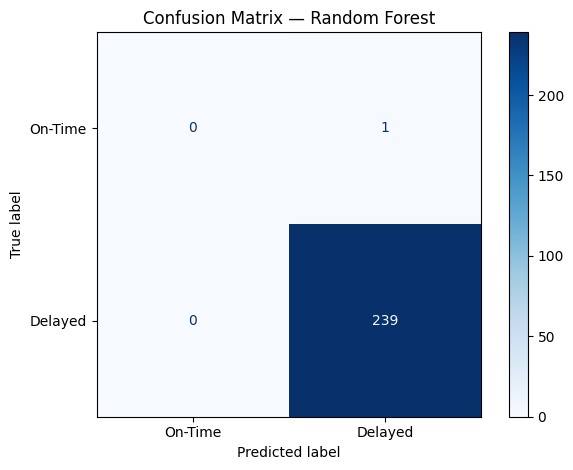

In [20]:
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On-Time','Delayed'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()


## 7. Cross-Validation


In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
print('Stratified 5-Fold ROC-AUC scores:', scores.round(4))
print('Mean:', round(scores.mean(), 4), '| Std:', round(scores.std(), 4))


Stratified 5-Fold ROC-AUC scores: [   nan 0.9791 0.4561 0.9498 0.9916]
Mean: nan | Std: nan


## 8. Feature Importance


In [22]:
rf_step   = model.named_steps['rf']
feat_names = model.named_steps['prep'].get_feature_names_out()

importance = pd.Series(
    rf_step.feature_importances_,
    index=feat_names
).sort_values(ascending=False)

print('Top 10 Features:')
print(importance.head(10))


Top 10 Features:
num__traffic_index               0.197936
num__day                         0.130463
num__weather_index               0.097660
num__calc_distance_km            0.080526
num__distance_km                 0.062777
num__base_production_per_week    0.058564
num__expected_time_hours         0.056454
cat__project_id_P37              0.049411
cat__project_id_P121             0.049345
cat__project_id_P62              0.028690
dtype: float64


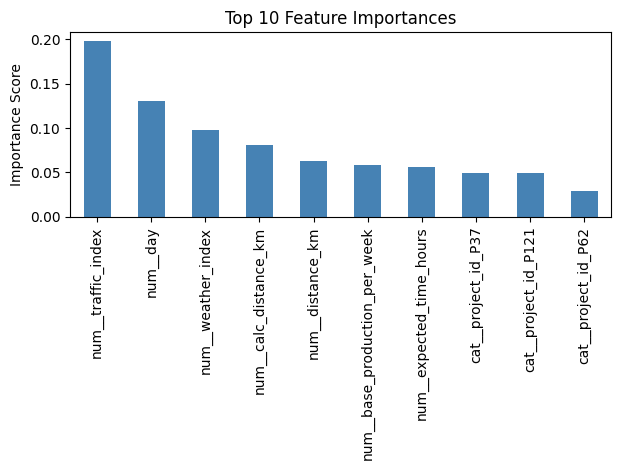

In [23]:
importance.head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Feature Importances')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()


## 9. Predictions & Risk Levels


In [24]:

X_test_copy = X_test.copy()
X_test_copy['predicted_delay_flag'] = pred
X_test_copy['delay_proba']          = model.predict_proba(X_test)[:, 1]


X_test_copy['risk_level'] = pd.cut(
    X_test_copy['delay_proba'],
    bins=[0, 0.4, 0.7, 1.0],
    labels=['Low', 'Medium', 'High']
)

print(X_test_copy['risk_level'].value_counts())


risk_level
High      240
Low         0
Medium      0
Name: count, dtype: int64


## 10. Reward-Based Optimization
> Reward framework from problem statement:
> - **+10** → On-time delivery predicted
> - **−15** → Delayed delivery predicted
> - **+5**  → High-priority project
> - **−2**  → Per excess delay hour


In [25]:
df['predicted_delay_flag'] = model.predict(X)
df['delay_proba']          = model.predict_proba(X)[:, 1]

df['reward_on_time']    = df['predicted_delay_flag'].apply(lambda x: 10 if x == 0 else -15)
df['reward_priority']   = df['priority_level'].map({'High': 5, 'Medium': 0, 'Low': 0})
df['reward_delay_pen']  = df['delay_hours'].clip(lower=0) * -2  # -2 per excess delay hour

df['reward_score'] = (
    df['reward_on_time']
    + df['reward_priority']
    + df['reward_delay_pen']
)

print('Reward score distribution:')
print(df['reward_score'].describe().round(2))


Reward score distribution:
count    1200.00
mean      -28.38
std         9.68
min       -66.54
25%       -34.25
50%       -27.31
75%       -21.22
max        12.14
Name: reward_score, dtype: float64


In [26]:
df['risk_level'] = pd.cut(
    df['delay_proba'],
    bins=[0, 0.4, 0.7, 1.0],
    labels=['Low', 'Medium', 'High']
)


## 11. Final Delivery Ranking & Prioritization Strategy


In [27]:
ranked = df.sort_values(by='reward_score', ascending=False)

ranked[[
    'delivery_id', 'project_id', 'priority_level',
    'predicted_delay_flag', 'delay_proba', 'risk_level',
    'delay_hours', 'reward_score'
]].head(20)


,delivery_id,project_id,priority_level,predicted_delay_flag,delay_proba,risk_level,delay_hours,reward_score
363,D364,P37,High,0,0.390,Low,1.43,12.14
1136,D1137,P121,Medium,0,0.325,Low,2.21,5.58
307,D308,P62,Low,0,0.415,Medium,2.89,4.22
349,D350,P197,High,1,1.000,High,0.15,-10.30
1063,D1064,P197,High,1,1.000,High,0.17,-10.34
1175,D1176,P197,High,1,1.000,High,0.22,-10.44
164,D165,P197,High,1,1.000,High,0.31,-10.62
10,D11,P197,High,1,1.000,High,0.39,-10.78
1119,D1120,P48,High,1,1.000,High,0.40,-10.80
1162,D1163,P198,High,1,1.000,High,0.49,-10.98


In [28]:
print('TOP 10 DELIVERIES TO PRIORITIZE (highest reward) ')
print(ranked[['delivery_id','project_id','priority_level','risk_level','reward_score']].head(10).to_string(index=False))

print('\n TOP 10 HIGH-RISK DELIVERIES (need intervention) ')
high_risk = df[df['risk_level']=='High'].sort_values('delay_proba', ascending=False)
print(high_risk[['delivery_id','project_id','priority_level','delay_proba','delay_hours']].head(10).to_string(index=False))


TOP 10 DELIVERIES TO PRIORITIZE (highest reward) 
delivery_id project_id priority_level risk_level  reward_score
       D364        P37           High        Low         12.14
      D1137       P121         Medium        Low          5.58
       D308        P62            Low     Medium          4.22
       D350       P197           High       High        -10.30
      D1064       P197           High       High        -10.34
      D1176       P197           High       High        -10.44
       D165       P197           High       High        -10.62
        D11       P197           High       High        -10.78
      D1120        P48           High       High        -10.80
      D1163       P198           High       High        -10.98

 TOP 10 HIGH-RISK DELIVERIES (need intervention) 
delivery_id project_id priority_level  delay_proba  delay_hours
      D1200       P164         Medium          1.0         7.54
         D1        P88           High          1.0        12.96
         D2   

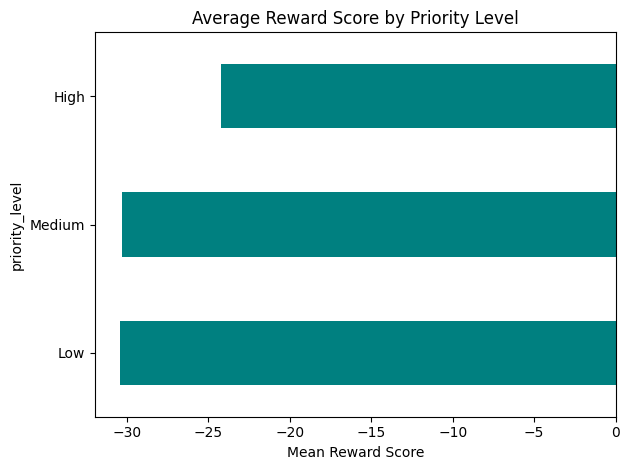

In [29]:
df.groupby('priority_level')['reward_score'].mean().sort_values().plot(kind='barh', color='teal')
plt.title('Average Reward Score by Priority Level')
plt.xlabel('Mean Reward Score')
plt.tight_layout()
plt.show()


Storing model for further use


In [30]:
import joblib

joblib.dump(model,"delay_model.pkl")

['delay_model.pkl']